In [129]:
import pandas as pd
import numpy as np

# File paths
input_file = 'sp100_sentiment_with_weighted.csv'
output_file = 'sp100_sentiment_with_w_type.csv'

try:
    # Load dataset
    df = pd.read_csv(input_file)
    
    # Verify 'type' column exists
    if 'type' not in df.columns:
        raise ValueError("Column 'type' not found in the dataset")
    
    # Define alpha values
    alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    
    # Create W_type columns for each alpha
    for alpha in alphas:
        df[f'W_type_alpha_{alpha}'] = np.where(
            df['type'] == 'post',
            alpha*df['W_sentiment'],
            np.where(df['type'] == 'comment', (1 - alpha)*df['W_sentiment'], np.nan)
        )
    
    # Save to new CSV
    df.to_csv(output_file, index=False)
    print(f"Saved modified dataset to {output_file}")
except Exception as e:
    print(f"Error processing file: {e}")

Saved modified dataset to sp100_sentiment_with_w_type.csv


In [181]:
import pandas as pd
qw = pd.read_csv('sp100_sentiment_with_w_type.csv')

In [182]:
qw = qw.rename(columns={'sentiment_compound': 'sentiment'})

In [185]:
qw = qw.rename(columns={'W_type_alpha_1.0': 'sentiment_compound'})

In [478]:
qw['sentiment_compound']=qw['sentiment']*qw['W_account']*qw['W_engagement']*qw['W_word']

In [187]:
qw.to_csv('sp100_sentiment_with_a1.0.csv', index=False)

Saved weekly sector-average sentiment to 1.0_sector.csv


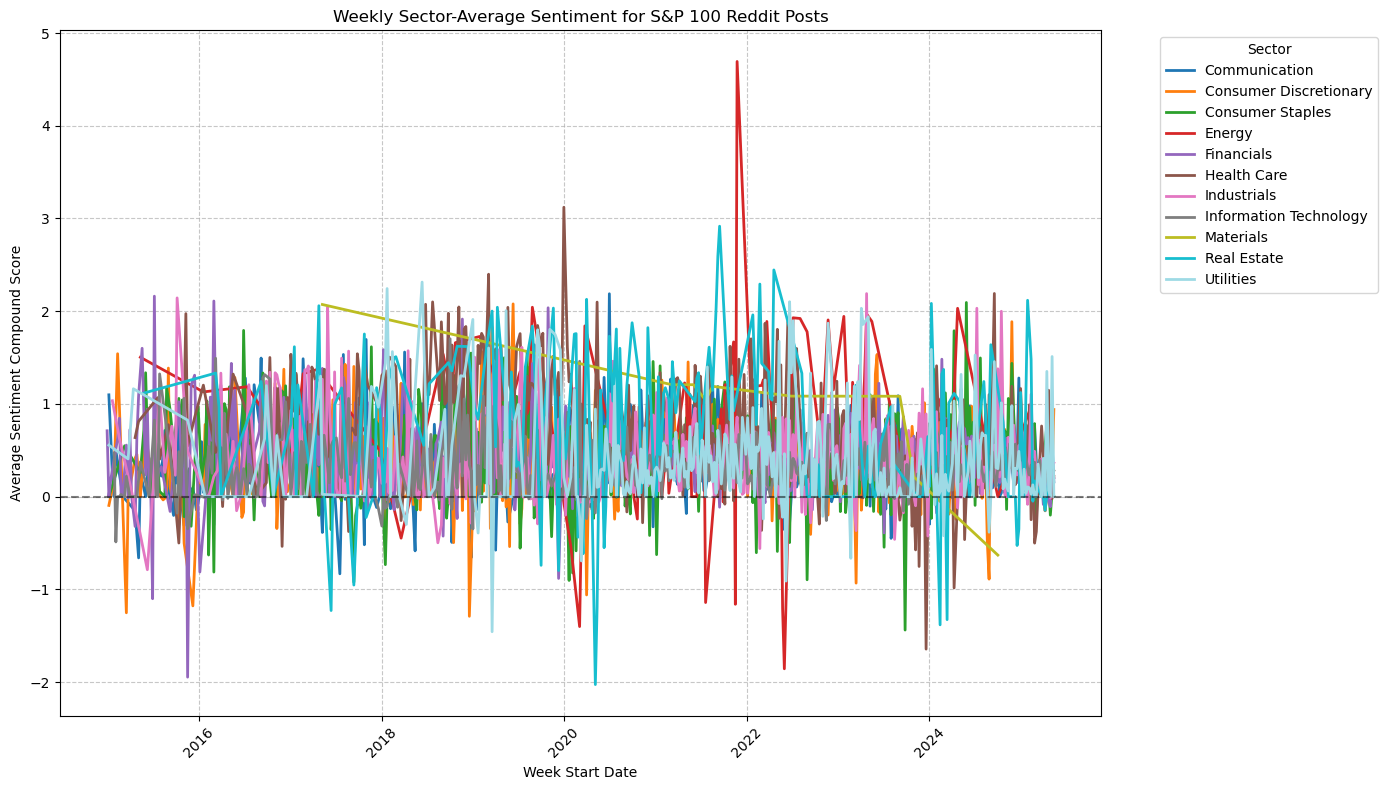


Sample of Weekly Sector-Average Sentiment (first 10 rows):
          sector week_start_date  avg_sentiment
0  Communication      2015-01-06       1.097850
1  Communication      2015-01-20       0.245742
2  Communication      2015-01-27       0.000000
3  Communication      2015-02-03       0.495634
4  Communication      2015-03-03       0.000000
5  Communication      2015-04-21      -0.151624
6  Communication      2015-05-05      -0.660736
7  Communication      2015-05-12       0.245393
8  Communication      2015-05-26       0.090191
9  Communication      2015-06-02       0.000000

Total valid posts: 155740
Rows filtered out (non-posts, invalid data, deleted authors): 0
Sectors: 11
Weeks covered: 542


In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Specify file paths
data_file = 'sp100_sentiment_with_a1.0.csv'
output_csv = '1.0_sector.csv'

try:
    # Load dataset
    df = pd.read_csv(data_file)
    
    # Filter valid posts (non-NaN, non-deleted authors, type == 'post')
    df = df[
        df['sector'].notna() &
        df['created_utc'].notna() &
        df['sentiment_compound'].notna()
    ]
    
    # Convert created_utc to datetime
    df['created_utc'] = pd.to_datetime(df['created_utc'])
    
    # Extract year and week start date (Monday)
    df['year'] = df['created_utc'].dt.year
    df['week_start_date'] = df['created_utc'].dt.to_period('W-MON').dt.start_time
    
    # Ensure sentiment_compound is numeric
    df['sentiment_compound'] = pd.to_numeric(df['sentiment_compound'], errors='coerce')
    
    # Step 1: Compute mean daily sentiment per stock
    daily_stock_sentiment = df.groupby(
        ['ticker', 'sector', df['created_utc'].dt.date]
    )['sentiment_compound'].mean().reset_index()
    daily_stock_sentiment['created_utc'] = pd.to_datetime(daily_stock_sentiment['created_utc'])
    
    # Step 2: Compute mean daily sentiment per sector
    daily_sector_sentiment = daily_stock_sentiment.groupby(
        ['sector', 'created_utc']
    )['sentiment_compound'].mean().reset_index()
    
    # Step 3: Assign week start date for daily sector sentiment
    daily_sector_sentiment['week_start_date'] = daily_sector_sentiment['created_utc'].dt.to_period('W-MON').dt.start_time
    
    # Step 4: Compute mean weekly sentiment per sector
    weekly_sector_sentiment = daily_sector_sentiment.groupby(
        ['sector', 'week_start_date']
    )['sentiment_compound'].mean().reset_index()
    weekly_sector_sentiment = weekly_sector_sentiment.rename(columns={'sentiment_compound': 'avg_sentiment'})
    
    # Save to CSV
    weekly_sector_sentiment.to_csv(output_csv, index=False)
    print(f"Saved weekly sector-average sentiment to {output_csv}")
    
    # --- Visualization: Weekly Sentiment by Sector ---
    plt.figure(figsize=(14, 8))
    
    # Get unique sectors
    sectors = sorted(weekly_sector_sentiment['sector'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))  # Distinct colors
    
    # Plot line for each sector
    for idx, sector in enumerate(sectors):
        sector_data = weekly_sector_sentiment[weekly_sector_sentiment['sector'] == sector]
        plt.plot(
            sector_data['week_start_date'],
            sector_data['avg_sentiment'],
            label=sector,
            color=colors[idx],
            linewidth=2
        )
    
    # Customize plot
    plt.xlabel('Week Start Date')
    plt.ylabel('Average Sentiment Compound Score')
    plt.title('Weekly Sector-Average Sentiment for S&P 100 Reddit Posts')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Neutral sentiment line
    plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()

    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Weekly Sector-Average Sentiment (first 10 rows):")
    print(weekly_sector_sentiment.head(10))
    print(f"\nTotal valid posts: {len(df)}")
    print(f"Rows filtered out (non-posts, invalid data, deleted authors): {len(pd.read_csv(data_file)) - len(df)}")
    print(f"Sectors: {len(sectors)}")
    print(f"Weeks covered: {len(weekly_sector_sentiment['week_start_date'].unique())}")
    
except Exception as e:
    print(f"Error processing file: {e}")

Saved weekly sector-average sentiment to alpha_sector.csv


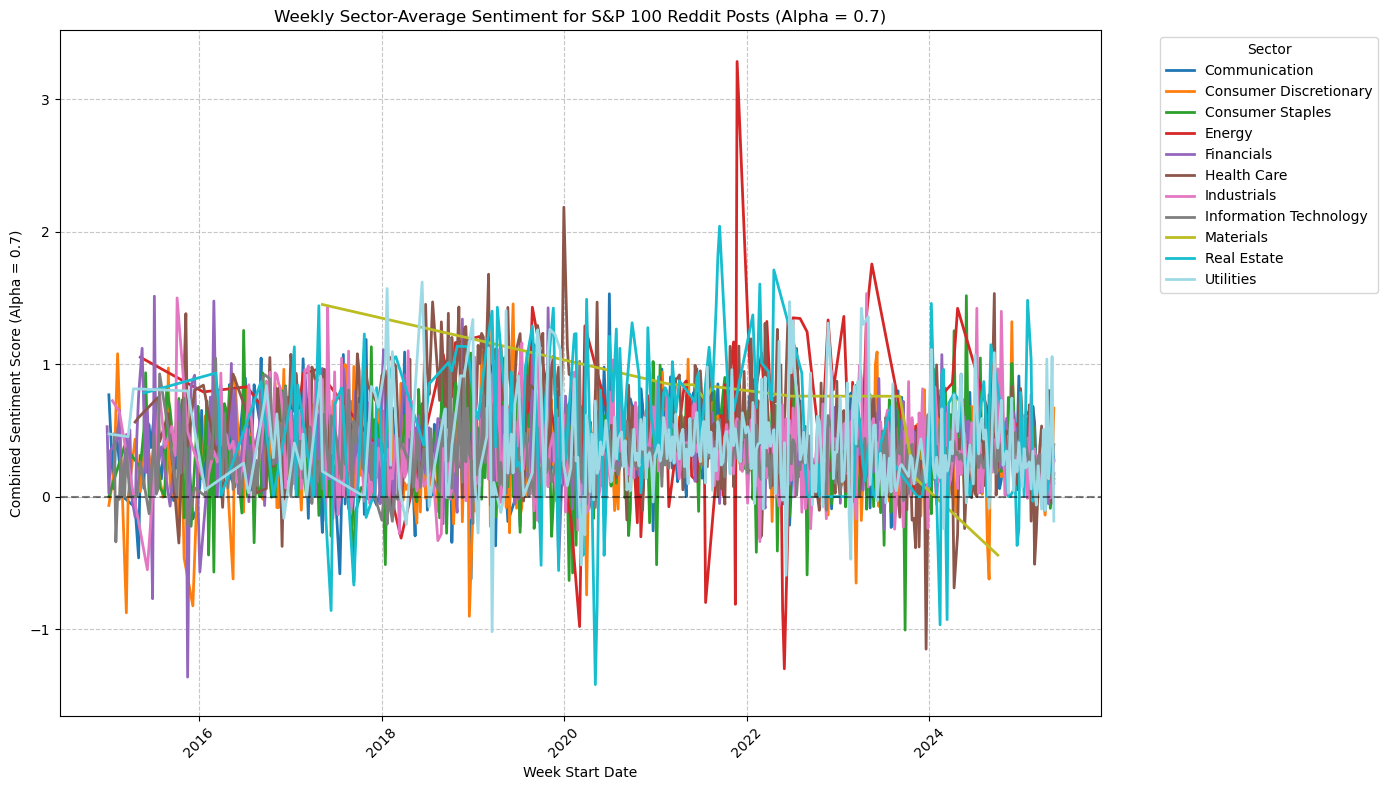


Sample of Weekly Sector-Average Sentiment (first 10 rows):
          sector week_start_date  combined_sentiment_alpha_0.5  \
0  Communication      2015-01-06                      0.548925   
1  Communication      2015-01-20                      0.209337   
2  Communication      2015-01-27                      0.096133   
3  Communication      2015-02-03                      0.536421   
4  Communication      2015-03-03                      0.000000   
5  Communication      2015-04-21                     -0.032552   
6  Communication      2015-05-05                     -0.330368   
7  Communication      2015-05-12                      0.357360   
8  Communication      2015-05-26                      0.045096   
9  Communication      2015-06-02                      0.979722   

   combined_sentiment_alpha_0.6  combined_sentiment_alpha_0.7  \
0                      0.658710                      0.768495   
1                      0.216618                      0.223899   
2                 

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Specify file paths
data_file = 'sp100_sentiment_with_weighted.csv'
output_csv = 'alpha_sector.csv'

try:
    # Load dataset
    df = pd.read_csv(data_file)
    
    # Filter valid posts (non-NaN, type == 'post' or 'comment')
    df = df[
        df['sector'].notna() &
        df['created_utc'].notna() &
        df['sentiment_compound'].notna() &
        df['W_sentiment'].notna() &
        df['W_total'].notna() &
        df['type'].isin(['post', 'comment'])
    ]
    
    # Convert created_utc to datetime
    df['created_utc'] = pd.to_datetime(df['created_utc'])
    
    # Extract year and week start date (Monday)
    df['year'] = df['created_utc'].dt.year
    df['week_start_date'] = df['created_utc'].dt.to_period('W-MON').dt.start_time
    
    # Apply alpha weights before grouping
    alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    for alpha in alphas:
        df[f'weighted_sentiment_alpha_{alpha}'] = np.where(
            df['type'] == 'post',
            alpha * df['W_sentiment'],
            (1 - alpha) * df['W_sentiment']
        )
    
    # Step 1: Compute mean daily sentiment per stock for each alpha
    daily_stock_sentiment = df.groupby(
        ['ticker', 'sector', df['created_utc'].dt.date]
    )[[f'weighted_sentiment_alpha_{alpha}' for alpha in alphas]].mean().reset_index()
    daily_stock_sentiment['created_utc'] = pd.to_datetime(daily_stock_sentiment['created_utc'])
    
    # Step 2: Compute mean daily sentiment per sector
    daily_sector_sentiment = daily_stock_sentiment.groupby(
        ['sector', 'created_utc']
    )[[f'weighted_sentiment_alpha_{alpha}' for alpha in alphas]].mean().reset_index()
    
    # Step 3: Assign week start date for daily sector sentiment
    daily_sector_sentiment['week_start_date'] = daily_sector_sentiment['created_utc'].dt.to_period('W-MON').dt.start_time
    
    # Step 4: Compute mean weekly sentiment per sector
    weekly_sector_sentiment = daily_sector_sentiment.groupby(
        ['sector', 'week_start_date']
    )[[f'weighted_sentiment_alpha_{alpha}' for alpha in alphas]].mean().reset_index()
    
    # Rename columns for clarity
    weekly_sector_sentiment = weekly_sector_sentiment.rename(columns={
        f'weighted_sentiment_alpha_{alpha}': f'combined_sentiment_alpha_{alpha}' for alpha in alphas
    })
    
    # Save to CSV
    weekly_sector_sentiment.to_csv(output_csv, index=False)
    print(f"Saved weekly sector-average sentiment to {output_csv}")
    
    # --- Visualization: Weekly Sentiment by Sector ---
    plt.figure(figsize=(14, 8))
    
    # Get unique sectors
    sectors = sorted(weekly_sector_sentiment['sector'].unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))  # Distinct colors
    
    # Plot line for each sector (using alpha = 0.7)
    for idx, sector in enumerate(sectors):
        sector_data = weekly_sector_sentiment[weekly_sector_sentiment['sector'] == sector]
        plt.plot(
            sector_data['week_start_date'],
            sector_data['combined_sentiment_alpha_0.7'],
            label=sector,
            color=colors[idx],
            linewidth=2
        )
    
    # Customize plot
    plt.xlabel('Week Start Date')
    plt.ylabel('Combined Sentiment Score (Alpha = 0.7)')
    plt.title('Weekly Sector-Average Sentiment for S&P 100 Reddit Posts (Alpha = 0.7)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Neutral sentiment line
    plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Weekly Sector-Average Sentiment (first 10 rows):")
    print(weekly_sector_sentiment.head(10))
    print(f"\nTotal valid posts: {len(df)}")
    print(f"Rows filtered out (non-posts, invalid data, deleted authors): {len(pd.read_csv(data_file)) - len(df)}")
    print(f"Sectors: {len(sectors)}")
    print(f"Weeks covered: {len(weekly_sector_sentiment['week_start_date'].unique())}")
    
except Exception as e:
    print(f"Error processing file: {e}")

Saved daily weighted sentiment to alpha_final.csv


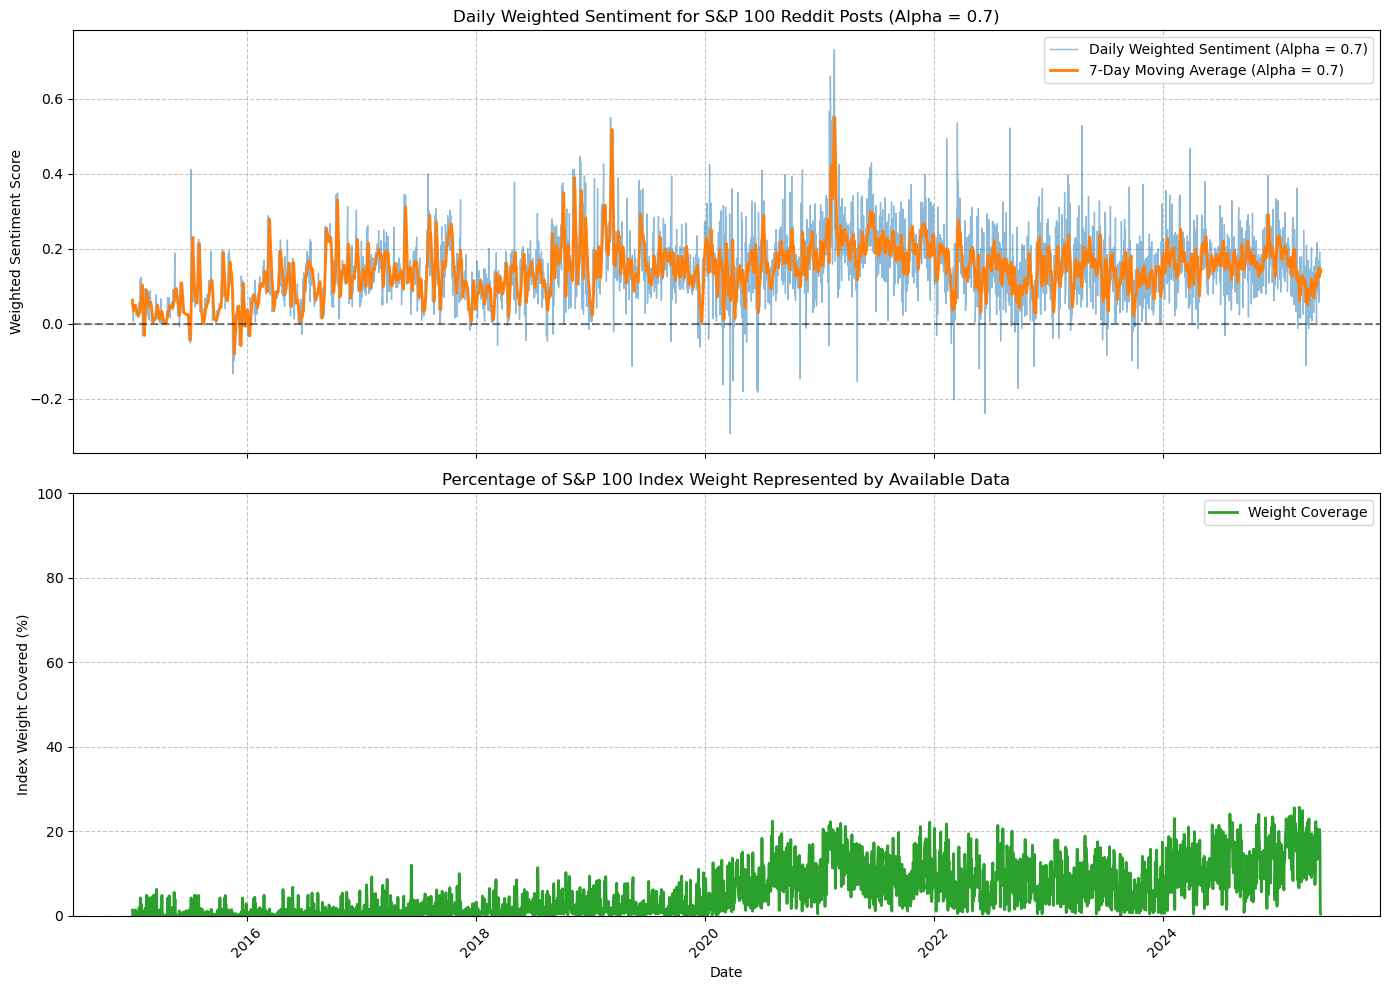


Sample of Daily Weighted Sentiment (first 10 rows):
        date  num_stocks  weight_percentage  weighted_sentiment_alpha_0.5  \
0 2015-01-02           1              1.325                      0.045213   
1 2015-01-03           0              0.000                      0.026774   
2 2015-01-04           0              0.000                      0.026774   
3 2015-01-05           1              0.195                      0.008336   
4 2015-01-06           2              0.305                      0.037644   
5 2015-01-07           0              0.000                      0.037644   
6 2015-01-08           0              0.000                      0.037644   
7 2015-01-09           2              1.280                      0.038285   
8 2015-01-10           1              0.130                      0.037003   
9 2015-01-11           0              0.000                      0.037644   

   weighted_sentiment_alpha_0.6  weighted_sentiment_alpha_0.7  \
0                      0.054255   

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
sentiment_file = 'sp100_sentiment_with_weighted.csv'
weights_file = 'Weights-05_25_2025.csv'
sector_sentiment_file = 'alpha_sector.csv'
output_csv = 'alpha_final.csv'

try:
    # Load datasets
    df_sentiment = pd.read_csv(sentiment_file)
    df_weights = pd.read_csv(weights_file)
    df_sector_sentiment = pd.read_csv(sector_sentiment_file)
    
    # Preprocess weights
    df_weights['weight'] = df_weights['Weight (%)'] / 100
    df_weights['Ticker'] = df_weights['Ticker'].str.upper()
    
    # Preprocess sector sentiment
    df_sector_sentiment['week_start_date'] = pd.to_datetime(df_sector_sentiment['week_start_date'])
    
    # Filter valid posts
    df_valid = df_sentiment[
        df_sentiment['created_utc'].notna() &
        df_sentiment['W_sentiment'].notna() &
        df_sentiment['type'].isin(['post', 'comment'])
    ]
    
    # Convert created_utc to datetime and extract date
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['date'] = df_valid['created_utc'].dt.date
    df_valid['ticker'] = df_valid['ticker'].str.upper()
    
    # Apply alpha weights before grouping
    alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    for alpha in alphas:
        df_valid[f'weighted_sentiment_alpha_{alpha}'] = np.where(
            df_valid['type'] == 'post',
            alpha * df_valid['W_sentiment'],
            (1 - alpha) * df_valid['W_sentiment']
        )
    
    # Compute mean daily sentiment per stock for each alpha
    daily_stock_sentiment = df_valid.groupby(['date', 'ticker', 'sector'])[
        [f'weighted_sentiment_alpha_{alpha}' for alpha in alphas]
    ].mean().reset_index()
    daily_stock_sentiment['date'] = pd.to_datetime(daily_stock_sentiment['date'])
    
    # Get all dates
    all_dates = pd.date_range(
        start=daily_stock_sentiment['date'].min(),
        end=daily_stock_sentiment['date'].max(),
        freq='D'
    )
    
    # Map dates to week start dates
    daily_stock_sentiment['week_start_date'] = daily_stock_sentiment['date'].dt.to_period('W-MON').dt.start_time
    
    # Initialize results
    results = []
    
    # Process each day
    for date in all_dates:
        # Get stocks with posts
        day_data = daily_stock_sentiment[daily_stock_sentiment['date'] == date]
        num_stocks = len(day_data)
        
        # Merge with weights
        day_data = day_data.merge(
            df_weights[['Ticker', 'weight', 'Sector']],
            left_on='ticker',
            right_on='Ticker',
            how='left'
        )
        day_data = day_data.dropna(subset=['weight'])
        
        # Calculate weight percentage (quality indicator)
        available_weight = day_data['weight'].sum()
        total_weight = df_weights['weight'].sum()
        weight_percentage = (available_weight / total_weight * 100) if total_weight > 0 else 0
        
        result = {
            'date': date,
            'num_stocks': num_stocks,
            'weight_percentage': weight_percentage
        }
        
        for alpha in alphas:
            col = f'weighted_sentiment_alpha_{alpha}'
            
            if num_stocks >= 25:
                # Approach 1: Use available data with normalized weights
                total_available_weight = day_data['weight'].sum()
                if total_available_weight > 0:
                    day_data['adjusted_weight'] = day_data['weight'] / total_available_weight
                    weighted_sentiment = (day_data[col] * day_data['adjusted_weight']).sum()
                else:
                    weighted_sentiment = 0
            else:
                # Approach 2: Supplement with sector-based imputation
                # Compute daily sector-average sentiment from available posts
                sector_avg = day_data.groupby('sector')[col].mean().to_dict()
                
                # Prepare all stocks
                temp_data = df_weights[['Ticker', 'weight', 'Sector']].copy()
                temp_data = temp_data.rename(columns={'Ticker': 'ticker', 'Sector': 'sector'})
                temp_data['date'] = date
                temp_data['week_start_date'] = pd.Timestamp(date).to_period('W-MON').start_time
                
                # Assign sentiments: posts or sector average
                temp_data = temp_data.merge(
                    day_data[['ticker', col]],
                    on='ticker',
                    how='left'
                )
                
                # Map weekly sector sentiment for the date
                week_sector = df_sector_sentiment[
                    df_sector_sentiment['week_start_date'] == temp_data['week_start_date'].iloc[0]
                ][['sector', f'combined_sentiment_alpha_{alpha}']]
                
                temp_data = temp_data.merge(
                    week_sector,
                    on='sector',
                    how='left'
                )
                
                # Fill missing sentiments: daily sector avg, then weekly sector avg, then 0
                temp_data[col] = temp_data.apply(
                    lambda x: x[col] if pd.notna(x[col])
                    else sector_avg.get(x['sector'], x[f'combined_sentiment_alpha_{alpha}'] if pd.notna(x[f'combined_sentiment_alpha_{alpha}']) else 0),
                    axis=1
                )
                
                # Normalize weights
                total_weight = temp_data['weight'].sum()
                if total_weight > 0:
                    temp_data['adjusted_weight'] = temp_data['weight'] / total_weight
                    weighted_sentiment = (temp_data[col] * temp_data['adjusted_weight']).sum()
                else:
                    weighted_sentiment = 0
            
            result[f'weighted_sentiment_alpha_{alpha}'] = weighted_sentiment
        
        results.append(result)
    
    # Create results DataFrame
    sentiment_by_day = pd.DataFrame(results)
    sentiment_by_day['date'] = pd.to_datetime(sentiment_by_day['date'])
    
    # Calculate 7-day moving average for each alpha
    for alpha in alphas:
        sentiment_by_day[f'sentiment_ma7_alpha_{alpha}'] = (
            sentiment_by_day[f'weighted_sentiment_alpha_{alpha}'].rolling(window=7, min_periods=1).mean()
        )
    
    # Save results
    sentiment_by_day.to_csv(output_csv, index=False)
    print(f"Saved daily weighted sentiment to {output_csv}")
    
    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Plot 1: Weighted Sentiment
    ax1.plot(
        sentiment_by_day['date'],
        sentiment_by_day['weighted_sentiment_alpha_0.7'],
        color='#1f77b4',
        alpha=0.5,
        label='Daily Weighted Sentiment (Alpha = 0.7)',
        linewidth=1
    )
    ax1.plot(
        sentiment_by_day['date'],
        sentiment_by_day['sentiment_ma7_alpha_0.7'],
        color='#ff7f0e',
        label='7-Day Moving Average (Alpha = 0.7)',
        linewidth=2
    )
    ax1.set_ylabel('Weighted Sentiment Score')
    ax1.set_title('Daily Weighted Sentiment for S&P 100 Reddit Posts (Alpha = 0.7)')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.legend()
    
    # Plot 2: Weight Percentage
    ax2.plot(
        sentiment_by_day['date'],
        sentiment_by_day['weight_percentage'],
        color='#2ca02c',
        label='Weight Coverage',
        linewidth=2
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Index Weight Covered (%)')
    ax2.set_title('Percentage of S&P 100 Index Weight Represented by Available Data')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    ax2.set_ylim(0, 100)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Daily Weighted Sentiment (first 10 rows):")
    print(sentiment_by_day.head(10))
    print(f"\nTotal valid posts: {len(df_valid)}")
    print(f"Rows filtered out: {len(df_sentiment) - len(df_valid)}")
    print(f"Stocks with missing weights: {len(set(df_valid['ticker']) - set(df_weights['Ticker']))}")
    print(f"Days with <25 stocks: {(sentiment_by_day['num_stocks'] < 25).sum()}")
    
except Exception as e:
    print(f"Error processing file: {e}")

Saved daily weighted sentiment to 1.0_final.csv


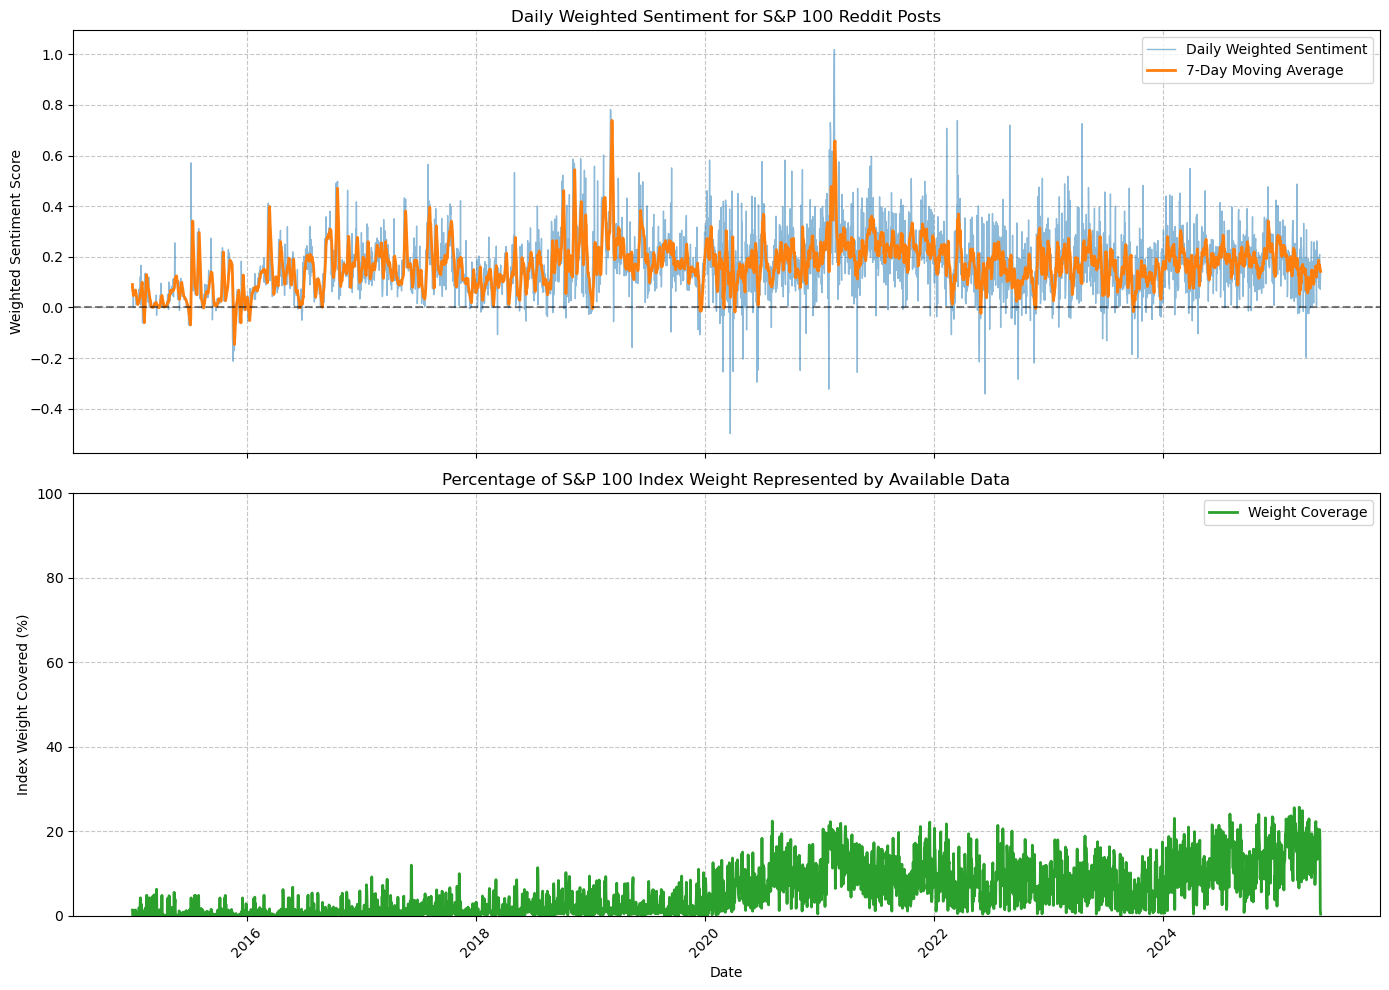


Sample of Daily Weighted Sentiment (first 10 rows):
        date  weighted_sentiment  num_stocks  weight_percentage  sentiment_ma7
0 2015-01-02            0.090425           1              1.325       0.090425
1 2015-01-03            0.046796           0              0.000       0.068611
2 2015-01-04            0.046796           0              0.000       0.061339
3 2015-01-05            0.003166           1              0.195       0.046796
4 2015-01-06            0.068638           2              0.305       0.051164
5 2015-01-07            0.068638           0              0.000       0.054077
6 2015-01-08            0.068638           0              0.000       0.056157
7 2015-01-09            0.071247           2              1.280       0.053417
8 2015-01-10            0.066030           1              0.130       0.056165
9 2015-01-11            0.068638           0              0.000       0.059285

Total valid posts: 155740
Rows filtered out: 0
Stocks with missing weights: 0

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
sentiment_file = 'sp100_sentiment_with_a1.0.csv'
weights_file = 'Weights-05_25_2025.csv'
sector_sentiment_file = '1.0_sector.csv'
output_csv = '1.0_final.csv'

try:
    # Load datasets
    df_sentiment = pd.read_csv(sentiment_file)
    df_weights = pd.read_csv(weights_file)
    df_sector_sentiment = pd.read_csv(sector_sentiment_file)
    
    # Preprocess weights
    df_weights['weight'] = df_weights['Weight (%)'] / 100
    df_weights['Ticker'] = df_weights['Ticker'].str.upper()
    
    # Preprocess sector sentiment
    df_sector_sentiment['week_start_date'] = pd.to_datetime(df_sector_sentiment['week_start_date'])
    
    # Filter valid posts
    df_valid = df_sentiment[
        df_sentiment['created_utc'].notna() &
        df_sentiment['sentiment_compound'].notna()
    ]
    
    # Convert created_utc to datetime and extract date
    df_valid['created_utc'] = pd.to_datetime(df_valid['created_utc'])
    df_valid['date'] = df_valid['created_utc'].dt.date
    df_valid['ticker'] = df_valid['ticker'].str.upper()
    
    # Compute mean daily sentiment per stock
    daily_stock_sentiment = df_valid.groupby(['date', 'ticker', 'sector'])['sentiment_compound'].mean().reset_index()
    daily_stock_sentiment['date'] = pd.to_datetime(daily_stock_sentiment['date'])
    
    # Get all dates
    all_dates = pd.date_range(
        start=daily_stock_sentiment['date'].min(),
        end=daily_stock_sentiment['date'].max(),
        freq='D'
    )
    
    # Map dates to week start dates
    daily_stock_sentiment['week_start_date'] = daily_stock_sentiment['date'].dt.to_period('W-MON').dt.start_time
    
    # Initialize results
    results = []
    
    # Process each day
    for date in all_dates:
        # Get stocks with posts
        day_data = daily_stock_sentiment[daily_stock_sentiment['date'] == date]
        num_stocks = len(day_data)
        
        # Merge with weights
        day_data = day_data.merge(
            df_weights[['Ticker', 'weight', 'Sector']],
            left_on='ticker',
            right_on='Ticker',
            how='left'
        )
        day_data = day_data.dropna(subset=['weight'])
        
        # Calculate weight percentage (quality indicator)
        available_weight = day_data['weight'].sum()
        total_weight = df_weights['weight'].sum()
        weight_percentage = (available_weight / total_weight * 100) if total_weight > 0 else 0
        
        if num_stocks >= 25:
            # Approach 1: Use available data with normalized weights
            total_available_weight = day_data['weight'].sum()
            if total_available_weight > 0:
                day_data['adjusted_weight'] = day_data['weight'] / total_available_weight
                weighted_sentiment = (day_data['sentiment_compound'] * day_data['adjusted_weight']).sum()
            else:
                weighted_sentiment = 0
        else:
            # Approach 2: Supplement with sector-based imputation
            # Compute daily sector-average sentiment from available posts
            sector_avg = day_data.groupby('sector')['sentiment_compound'].mean().to_dict()
            
            # Prepare all stocks
            temp_data = df_weights[['Ticker', 'weight', 'Sector']].copy()
            temp_data = temp_data.rename(columns={'Ticker': 'ticker', 'Sector': 'sector'})
            temp_data['date'] = date
            temp_data['week_start_date'] = pd.Timestamp(date).to_period('W-MON').start_time
            
            # Assign sentiments: posts or sector average
            temp_data = temp_data.merge(
                day_data[['ticker', 'sentiment_compound']],
                on='ticker',
                how='left'
            )
            
            # Map weekly sector sentiment for the date
            week_sector = df_sector_sentiment[
                df_sector_sentiment['week_start_date'] == temp_data['week_start_date'].iloc[0]
            ][['sector', 'avg_sentiment']]
            
            temp_data = temp_data.merge(
                week_sector,
                on='sector',
                how='left'
            )
            
            # Fill missing sentiments: daily sector avg, then weekly sector avg, then 0
            temp_data['sentiment_compound'] = temp_data.apply(
                lambda x: x['sentiment_compound'] if pd.notna(x['sentiment_compound'])
                else sector_avg.get(x['sector'], x['avg_sentiment'] if pd.notna(x['avg_sentiment']) else 0),
                axis=1
            )
            
            # Normalize weights
            total_weight = temp_data['weight'].sum()
            if total_weight > 0:
                temp_data['adjusted_weight'] = temp_data['weight'] / total_weight
                weighted_sentiment = (temp_data['sentiment_compound'] * temp_data['adjusted_weight']).sum()
            else:
                weighted_sentiment = 0
        
        results.append({
            'date': date,
            'weighted_sentiment': weighted_sentiment,
            'num_stocks': num_stocks,
            'weight_percentage': weight_percentage
        })
    
    # Create results DataFrame
    sentiment_by_day = pd.DataFrame(results)
    sentiment_by_day['date'] = pd.to_datetime(sentiment_by_day['date'])
    
    # Calculate 7-day moving average
    sentiment_by_day['sentiment_ma7'] = sentiment_by_day['weighted_sentiment'].rolling(window=7, min_periods=1).mean()
    
    # Save results
    sentiment_by_day.to_csv(output_csv, index=False)
    print(f"Saved daily weighted sentiment to {output_csv}")
    
    # --- Visualization ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Plot 1: Weighted Sentiment
    ax1.plot(
        sentiment_by_day['date'],
        sentiment_by_day['weighted_sentiment'],
        color='#1f77b4',
        alpha=0.5,
        label='Daily Weighted Sentiment',
        linewidth=1
    )
    ax1.plot(
        sentiment_by_day['date'],
        sentiment_by_day['sentiment_ma7'],
        color='#ff7f0e',
        label='7-Day Moving Average',
        linewidth=2
    )
    ax1.set_ylabel('Weighted Sentiment Score')
    ax1.set_title('Daily Weighted Sentiment for S&P 100 Reddit Posts')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax1.legend()
    
    # Plot 2: Weight Percentage
    ax2.plot(
        sentiment_by_day['date'],
        sentiment_by_day['weight_percentage'],
        color='#2ca02c',
        label='Weight Coverage',
        linewidth=2
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Index Weight Covered (%)')
    ax2.set_title('Percentage of S&P 100 Index Weight Represented by Available Data')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    ax2.set_ylim(0, 100)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display plot
    plt.show()
    
    # Print summary
    print("\nSample of Daily Weighted Sentiment (first 10 rows):")
    print(sentiment_by_day.head(10))
    print(f"\nTotal valid posts: {len(df_valid)}")
    print(f"Rows filtered out: {len(df_sentiment) - len(df_valid)}")
    print(f"Stocks with missing weights: {len(set(df_valid['ticker']) - set(df_weights['Ticker']))}")
    print(f"Days with <25 stocks: {(sentiment_by_day['num_stocks'] < 25).sum()}")
    
except Exception as e:
    print(f"Error processing file: {e}")

In [13]:
import yfinance as yf
ticker = ["^OEX"]
stonks = yf.download(ticker, start = "2015-01-01", end= "2025-05-16").copy()
all_days =pd.date_range(start = "2015-01-01", end ="2025-05-16",freq="D")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [169]:
close = stonks.Close
close=close.reindex(all_days)
close = close.fillna(method="ffill")
close["% Change"]=close["^OEX"].pct_change()
close.index.name="Date"

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_12076\251630317.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  close = close.fillna(method="ffill")


In [193]:
af = pd.read_csv("1.0_final.csv", index_col=[0])
af.index.name="Date"
af.index = pd.to_datetime(af.index, errors='coerce')

In [195]:
merged = pd.merge(close, af, left_on='Date', right_index=True, how='inner')

In [197]:
merged

,^OEX,% Change,weighted_sentiment,num_stocks,weight_percentage,sentiment_ma7
Date,,,,,,
2015-01-02,907.500000,NaN,0.090425,1,1.325,0.090425
2015-01-03,907.500000,0.000000,0.046796,0,0.000,0.068611
2015-01-04,907.500000,0.000000,0.046796,0,0.000,0.061339
2015-01-05,891.039978,-0.018138,0.003166,1,0.195,0.046796
2015-01-06,883.960022,-0.007946,0.068638,2,0.305,0.051164
...,...,...,...,...,...,...
2025-05-12,2833.699951,0.035701,0.077278,15,19.525,0.159375
2025-05-13,2858.500000,0.008752,0.199531,22,16.130,0.153557
2025-05-14,2869.570068,0.003873,0.209443,20,20.385,0.166815


In [177]:
merged.columns

Index(['^OEX', '% Change', 'weighted_sentiment', 'num_stocks',
       'weight_percentage', 'sentiment_ma7'],
      dtype='object')

In [199]:
print(merged['% Change'].corr(merged['weighted_sentiment']))
print(merged['% Change'].corr(merged['sentiment_ma7']))
print(merged['^OEX'].corr(merged['weighted_sentiment']))
print(merged['^OEX'].corr(merged['sentiment_ma7']))

0.028717752024459378
0.008822657223140816
0.17089368779188982
0.2491550026137744


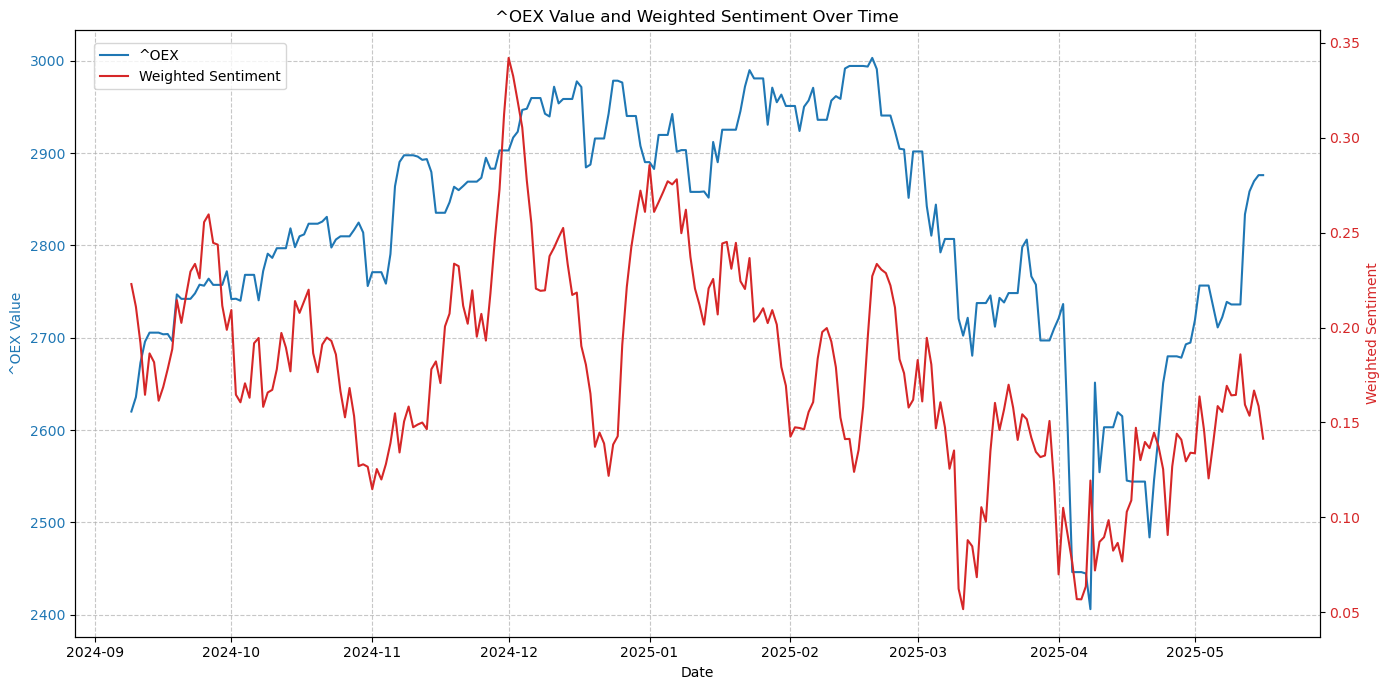

In [201]:
# Set up the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot ^OEX on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('^OEX Value', color=color)
ax1.plot(merged.tail(250).index, merged.tail(250)['^OEX'], color=color, label='^OEX')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# Create a second y-axis for the sentiment score
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Weighted Sentiment', color=color) # Label changed to reflect 'weighted_sentiment'
ax2.plot(merged.tail(250).index, merged.tail(250)['sentiment_ma7'], color=color, label='Weighted Sentiment')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('^OEX Value and Weighted Sentiment Over Time')
fig.tight_layout() # Adjust layout to prevent labels from overlapping
# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(0.01, 0.99))

plt.show()

In [96]:
merged.columns

Index(['^OEX', '% Change', 'weighted_sentiment', 'num_stocks',
       'weight_percentage', 'sentiment_ma7'],
      dtype='object')

Saved rolling correlation plot to testing/rolling_correlation_weighted_sentiment_W_account.png


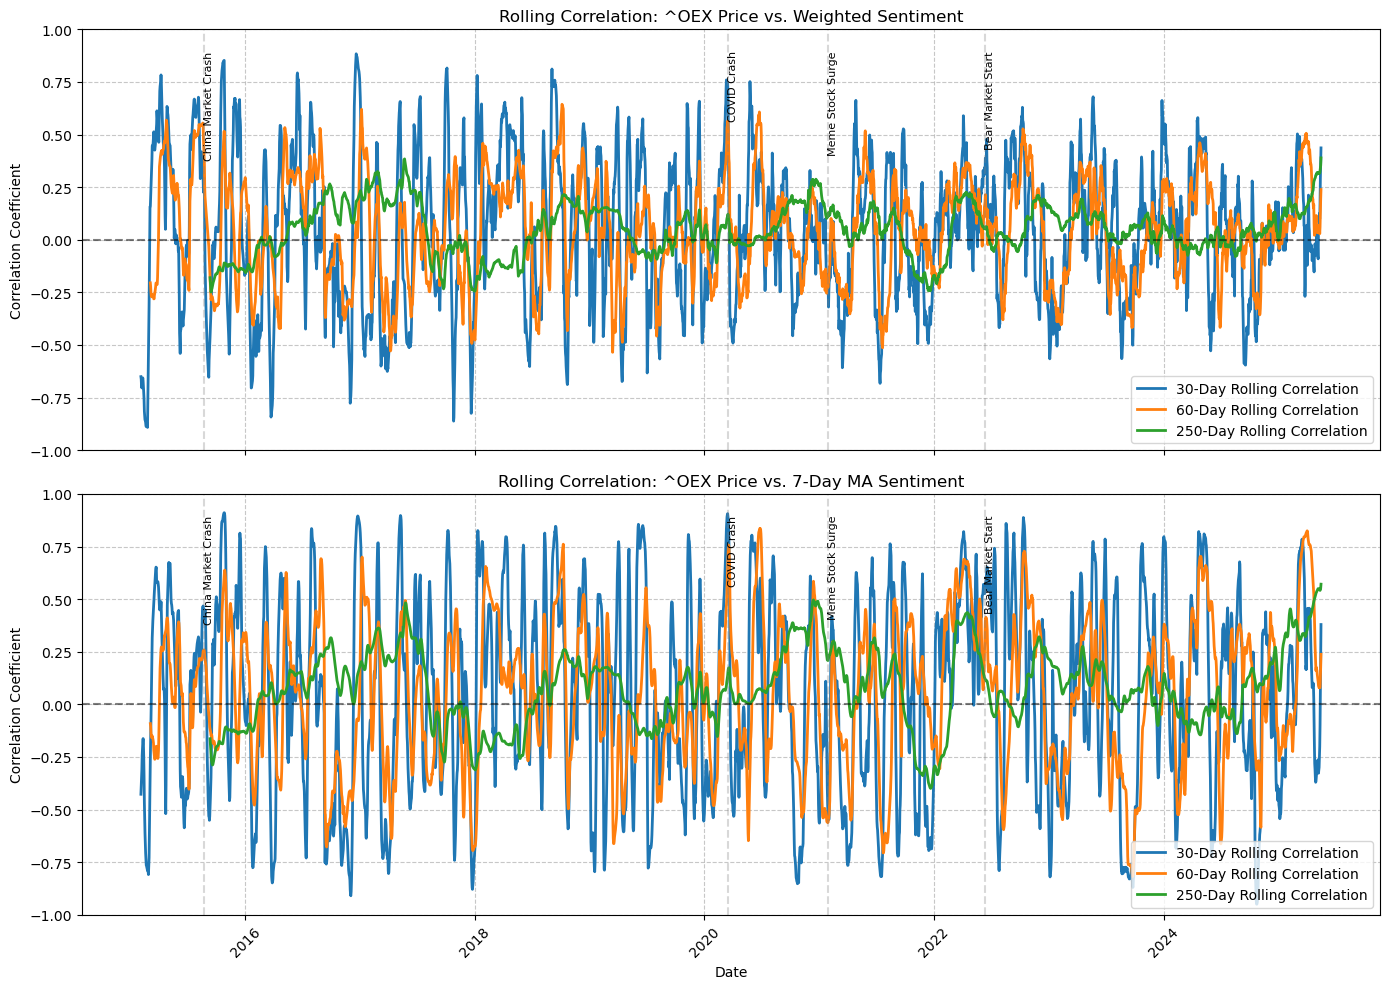


Correlation Analysis:
Overall ^OEX vs. weighted_sentiment: 0.3051
Last 1500 ^OEX vs. sentiment_ma7: 0.0191
Last 250 ^OEX vs. weighted_sentiment: 0.3889

30-Day Rolling Correlation Stats:
Weighted Sentiment: Mean=0.0462, Std=0.3408
Sentiment MA7: Mean=0.0443, Std=0.4601

60-Day Rolling Correlation Stats:
Weighted Sentiment: Mean=0.0437, Std=0.2392
Sentiment MA7: Mean=0.0472, Std=0.3399

250-Day Rolling Correlation Stats:
Weighted Sentiment: Mean=0.0473, Std=0.1181
Sentiment MA7: Mean=0.0771, Std=0.1781


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the index is datetime (assuming merged has a Date index)
merged.index = pd.to_datetime(merged.index)

# Define window sizes for rolling correlation
windows = [30, 60, 250]  # Days
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Colors for each window

# Initialize plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Rolling correlation of ^OEX vs. weighted_sentiment
for window, color in zip(windows, colors):
    rolling_corr = merged['^OEX'].rolling(window=window).corr(merged['weighted_sentiment'])
    ax1.plot(
        rolling_corr.index,
        rolling_corr,
        label=f'{window}-Day Rolling Correlation',
        color=color,
        linewidth=2
    )

ax1.set_ylabel('Correlation Coefficient')
ax1.set_title('Rolling Correlation: ^OEX Price vs. Weighted Sentiment')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.legend()
ax1.set_ylim(-1, 1)

# Plot 2: Rolling correlation of ^OEX vs. sentiment_ma7
for window, color in zip(windows, colors):
    rolling_corr = merged['^OEX'].rolling(window=window).corr(merged['sentiment_ma7'])
    ax2.plot(
        rolling_corr.index,
        rolling_corr,
        label=f'{window}-Day Rolling Correlation',
        color=color,
        linewidth=2
    )

ax2.set_xlabel('Date')
ax2.set_ylabel('Correlation Coefficient')
ax2.set_title('Rolling Correlation: ^OEX Price vs. 7-Day MA Sentiment')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.legend()
ax2.set_ylim(-1, 1)

# Add key market events (adjust dates as needed)
events = {
    '2015-08-24': 'China Market Crash',
    '2020-03-16': 'COVID Crash',
    '2021-01-27': 'Meme Stock Surge',
    '2022-06-13': 'Bear Market Start'
}
for date, label in events.items():
    date = pd.to_datetime(date)
    if date in merged.index:
        ax1.axvline(x=date, color='gray', linestyle='--', alpha=0.3)
        ax2.axvline(x=date, color='gray', linestyle='--', alpha=0.3)
        ax1.text(date, 0.9, label, rotation=90, verticalalignment='top', fontsize=8)
        ax2.text(date, 0.9, label, rotation=90, verticalalignment='top', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()

# Save plot
output_plot = 'testing/rolling_correlation_weighted_sentiment_W_account.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
print(f"Saved rolling correlation plot to {output_plot}")

# Display plot
plt.show()

# Print correlation for last 1500 and 250 rows
print("\nCorrelation Analysis:")
print(f"Overall ^OEX vs. weighted_sentiment: {merged['^OEX'].corr(merged['weighted_sentiment']):.4f}")
print(f"Last 1500 ^OEX vs. sentiment_ma7: {merged['^OEX'].tail(1500).corr(merged['sentiment_ma7'].tail(1500)):.4f}")
print(f"Last 250 ^OEX vs. weighted_sentiment: {merged['^OEX'].tail(250).corr(merged['weighted_sentiment'].tail(250)):.4f}")

# Summary statistics for rolling correlations
for window in windows:
    rolling_corr_ws = merged['^OEX'].rolling(window=window).corr(merged['weighted_sentiment'])
    rolling_corr_ma7 = merged['^OEX'].rolling(window=window).corr(merged['sentiment_ma7'])
    print(f"\n{window}-Day Rolling Correlation Stats:")
    print(f"Weighted Sentiment: Mean={rolling_corr_ws.mean():.4f}, Std={rolling_corr_ws.std():.4f}")
    print(f"Sentiment MA7: Mean={rolling_corr_ma7.mean():.4f}, Std={rolling_corr_ma7.std():.4f}")